In [ ]:
import ROOT, os, json, copy
from pathlib import Path
import uproot
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize

from ddfUtils.mpl_styling import add_label

plt.style.use("root")

ROOT.gROOT.SetBatch(True)

In [ ]:
input_file = "/eos/user/i/idioniso/sndMuTri/out/topological_criteria_scan_cutset8.root"

with uproot.open(input_file) as f_in:
    df = f_in["topological_scan"].arrays(library="pd")
    meta = json.loads(str(f_in["metadata"])) if "metadata" in f_in else {}

print(f"    Loaded {len(df):,} criteria configurations.")
print(meta)

    Loaded 3,366 criteria configurations.


In [3]:
df.columns

Index(['index', 'regime', 'label', 'clean_label', 'data_events',
       'data_rej_pct', 'gallery_events', 'gallery_surv_pct',
       'gallery_6640_events', 'gallery_6640_surv_pct', 'gallery_all_events',
       'gallery_all_surv_pct', 'bkg_mc_total', 'bkg_trimuon', 'bkg_pmu',
       'yield_direct_rock', 'eff_direct_rock', 'sig_data_direct_rock',
       'sig_mc_direct_rock', 'yield_direct_tgt', 'eff_direct_tgt',
       'sig_data_direct_tgt', 'sig_mc_direct_tgt', 'yield_direct_mu',
       'eff_direct_mu', 'sig_data_direct_mu', 'sig_mc_direct_mu',
       'yield_gamma_rock', 'eff_gamma_rock', 'sig_data_gamma_rock',
       'sig_mc_gamma_rock', 'yield_gamma_tgt', 'eff_gamma_tgt',
       'sig_data_gamma_tgt', 'sig_mc_gamma_tgt', 'yield_gamma_mu',
       'eff_gamma_mu', 'sig_data_gamma_mu', 'sig_mc_gamma_mu',
       'yield_annihil_rock', 'eff_annihil_rock', 'sig_data_annihil_rock',
       'sig_mc_annihil_rock', 'yield_annihil_tgt', 'eff_annihil_tgt',
       'sig_data_annihil_tgt', 'sig_mc_annih

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


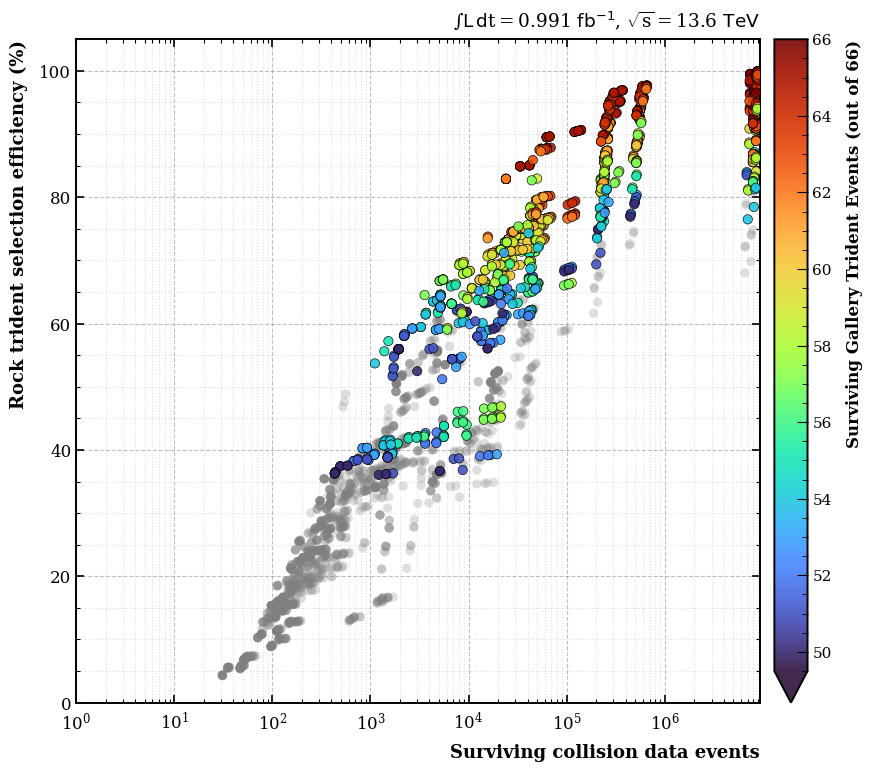

In [4]:
max_data_events = None
cmap_name = "turbo"

x = df["data_events"].to_numpy()
y = df["eff_direct_rock"].to_numpy()
z = df["gallery_events"].to_numpy()

tot_gal = meta.get(
    "sample_statistics", {}
).get("total_input_gallery_events", int(df["gallery_events"].max()))
lumi_full = meta.get("normalization", {}).get("target_luminosity_fb", 0.991586)
fig, ax = plt.subplots(figsize=(9, 8))

if max_data_events is not None and max_data_events > 0:
  mask = x <= max_data_events
else:
  mask = np.ones(len(x), dtype=bool)

x_plot = x[mask]
y_plot = y[mask]
z_plot = z[mask]

z_max = z_plot.max()
z_min_colored = 0.75 * z_max

# Split into under-threshold (grey) and in-range (colored) points
under_mask = z_plot < z_min_colored
colored_mask = ~under_mask

# 1. Plot under-threshold points with lower alpha
ax.scatter(
    x_plot[under_mask],
    y_plot[under_mask],
    color="grey",
    s=45,
    alpha=0.25,  # Adjusted transparency for grey points
    edgecolors="none",
    zorder=2,
)

# 2. Plot in-range points with colormap and full visibility
sc = ax.scatter(
    x_plot[colored_mask],
    y_plot[colored_mask],
    c=z_plot[colored_mask],
    cmap=cmap_name,
    vmin=z_min_colored,
    vmax=z_max,
    s=45,
    alpha=0.90,
    edgecolors="black",
    linewidths=0.5,
    zorder=3,
)

# 3. Add colorbar with extend="min"
cbar = plt.colorbar(sc, ax=ax, pad=0.02, fraction=0.046, extend="min")
cbar.set_label(
    f"Surviving Gallery Trident Events (out of {tot_gal})",
    fontsize=12,
    fontweight="bold",
    labelpad=10,
)
cbar.ax.tick_params(labelsize=11)

ax.set_xlabel(
    "Surviving collision data events",
    fontsize=13,
    fontweight="bold",
    labelpad=8,
)
ax.set_ylabel(
    "Rock trident selection efficiency (%)",
    fontsize=13,
    fontweight="bold",
    labelpad=8,
)

ax.set_ylim(0, 105)
if max_data_events is not None and max_data_events > 0:
  ax.set_xlim(1, max_data_events)
  ax.set_xscale("log")
else:
  ax.set_xlim(1, max(x) * 1.05)
  ax.set_xscale("log")

# Grid & Ticks
ax.grid(True, which="major", linestyle="--", alpha=0.5, color="gray", zorder=1)
ax.minorticks_on()
ax.grid(True, which="minor", linestyle=":", alpha=0.25, color="gray", zorder=1)
ax.tick_params(axis="both", which="major", labelsize=12, length=6, width=1.2)
ax.tick_params(axis="both", which="minor", length=3, width=0.8)

add_label(mainText="", extraText="", lumi=0.991, com=13.6, style="formal", ax=ax)


plt.tight_layout()
plt.show()
plt.close()

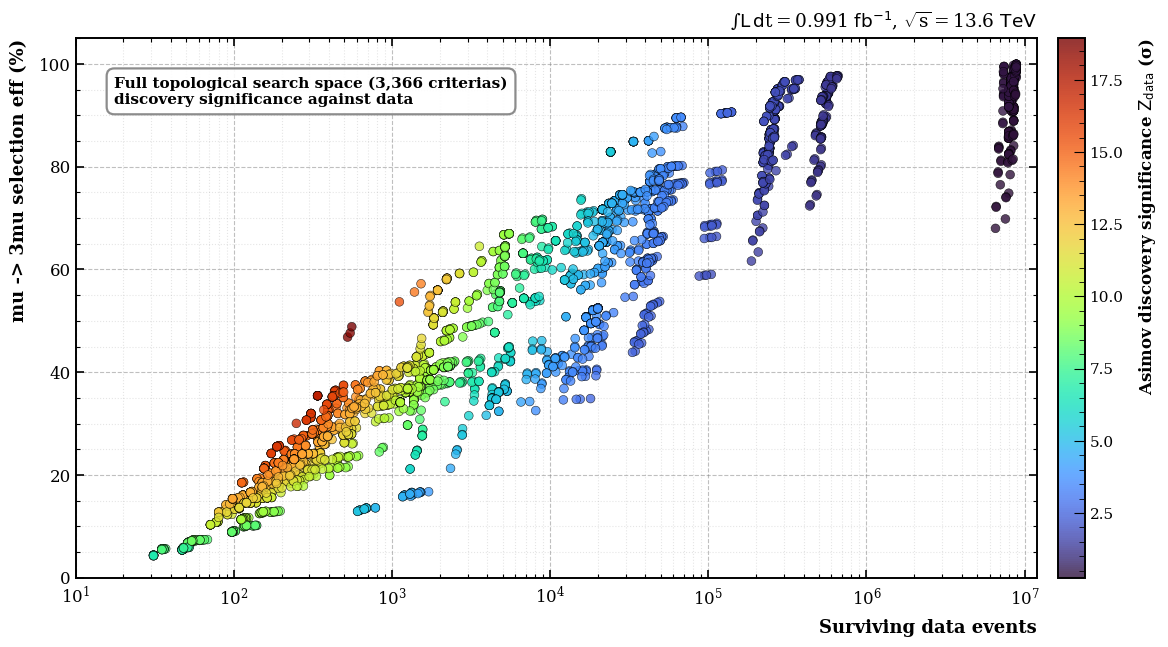

In [ ]:
x_data = df["data_events"].to_numpy()
y_rock_eff = df["eff_direct_rock"].to_numpy()
z_sig_data = df["sig_data_direct_rock"].to_numpy()

fig, ax = plt.subplots(figsize=(16*0.75, 9*0.75))

sc = ax.scatter(
    x_data,
    y_rock_eff,
    c=z_sig_data,
    cmap="turbo",
    s=40,
    alpha=0.80,
    edgecolors="black",
    linewidths=0.4,
    zorder=3,
)


cbar = plt.colorbar(sc, ax=ax, pad=0.02, fraction=0.046)
cbar.set_label(
    r"Asimov discovery significance $\mathcal{Z}_{\mathrm{data}}$"
    r" ($\sigma$)",
    fontsize=12,
    fontweight="bold",
    labelpad=10,
)
cbar.ax.tick_params(labelsize=11)

ax.set_xscale("log")
ax.set_xlim(10, 1.2e7)
ax.set_ylim(0, 105)
ax.set_xlabel(
    "Surviving data events",
    fontsize=13,
    fontweight="bold",
    labelpad=8,
)
ax.set_ylabel(
    "mu -> 3mu selection eff (%)",
    fontsize=13,
    fontweight="bold",
    labelpad=8,
)

ax.grid(
    True, which="major", linestyle="--", alpha=0.5, color="gray", zorder=1
)
ax.minorticks_on()
ax.grid(
    True, which="minor", linestyle=":", alpha=0.20, color="gray", zorder=1
)
ax.tick_params(
    axis="both", which="major", labelsize=12, length=6, width=1.2
)
ax.tick_params(
    axis="both", which="minor", labelsize=10, length=3, width=0.8
)


add_label(
    loc="top-left",
    supp_loc="top-right",
    mainText="",extraText="",
    lumi=0.991,
    com=13.6,
    style="formal",
    ax=ax,
)


ax.text(
    0.04,
    0.93,
    f"Full topological search space ({len(df):,} criterias)\n"
    "significance against data",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray",
        alpha=0.90,
    ),
    zorder=5,
)

plt.tight_layout()
plt.show()
plt.close()

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# ==============================================================================
# 1. PREPARE DATA
# ==============================================================================
x_data = df["data_events"].to_numpy()
y_rock_eff = df["eff_direct_rock"].to_numpy()
z_gal_6640 = (
    df["gallery_6640_events"].to_numpy()
    if "gallery_6640_events" in df.columns
    else df["gallery_events"].to_numpy()
)

zoom_mask = x_data <= 2500
x_zoom = x_data[zoom_mask]
y_zoom = y_rock_eff[zoom_mask]
z_zoom = z_gal_6640[zoom_mask]

# ==============================================================================
# 2. PLOTTING
# ==============================================================================
fig, ax = plt.subplots(figsize=(8.0, 7.5))

sc = ax.scatter(
    x_zoom,
    y_zoom,
    c=z_zoom,
    cmap="turbo",
    s=45,
    alpha=0.75,
    edgecolors="black",
    linewidths=0.4,
    zorder=3,
)

cbar = plt.colorbar(sc, ax=ax, pad=0.02, fraction=0.046)
cbar.set_label(
    "Run 6640 gallery events (out of 66)",
    fontsize=11.5,
    fontweight="bold",
    labelpad=10,
)
cbar.ax.tick_params(labelsize=10.5)

ax.set_xlim(0, 2500)
ax.set_ylim(0, 75)
ax.set_xlabel(
    r"Surviving data events ($B_{\mathrm{data}}$)",
    fontsize=12,
    fontweight="bold",
    labelpad=8,
)
ax.set_ylabel(
    r"$\epsilon_{\mathrm{rock}}$ (%)",
    fontsize=12,
    fontweight="bold",
    labelpad=8,
)


ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", linestyle="--", alpha=0.45, color="gray", zorder=1)
ax.grid(True, which="minor", linestyle=":", alpha=0.20, color="gray", zorder=1)
ax.tick_params(axis="both", which="major", labelsize=11, length=6, width=1.2)
ax.tick_params(axis="both", which="minor", labelsize=9, length=3, width=0.8)

# Shaded Sweet Spot Area
rect = Rectangle(
    (0, 44),
    2000,
    26,
    linewidth=1.2,
    edgecolor="#E63946",
    facecolor="#E63946",
    alpha=0.08,
    linestyle="--",
    zorder=2,
)
ax.add_patch(rect)

add_label(
    loc="top-left",
    supp_loc="top-right",
    mainText="", extraText="",
    suppText="(Run 6640)",
    lumi=0.991,
    com=13.6,
    style="formal",
    ax=ax,
)

# ==============================================================================
# 3. BENCHMARKS & ANNOTATIONS
# ==============================================================================
benchmarks = [
    {
        "label_pattern": "[SF(3,1) | DS(3,1)] & (SF_nc & DS_nc)",
        "title": "Optimal Balanced Trade-Off",
        "xytext": (-190, 24),  # Shifted further left/up to clear the star marker
        "color": "#E63946",
        "marker": "*",
        "size": 180,
    },
    {
        "label_pattern": "(SF_3 | DS_3) & (SF:AND & DS:OR)",
        "title": "Max Z_data Optimum",
        "xytext": (28, -25),  # Shifted down/right away from the star and upper box
        "color": "#2A9D8F",
        "marker": "D",
        "size": 130,
    },
    {
        "label_pattern": "[SF(3,1) | DS(3,1)] & (SF:AND & DS:OR)",
        "title": "High Z_data Pure Mode",
        "xytext": (-190, -42),
        "color": "#E76F51",
        "marker": "^",
        "size": 130,
    },
    {
        "label_pattern": "SF(3,3)_AND & DS(1,0)_AND",
        "title": "Ultra-High Purity (N <= 100)",
        "xytext": (28, 20),
        "color": "#7209B7",
        "marker": "s",
        "size": 120,
    },
]

for bm in benchmarks:
    match = df[df["clean_label"] == bm["label_pattern"]]
    if match.empty:
        continue
    row = match.iloc[0]
    bx, by = row["data_events"], row["eff_direct_rock"]
    bz_data = row["sig_data_direct_rock"]
    bz_mc = row["sig_mc_direct_rock"]
    bgal_6640 = (
        int(row["gallery_6640_events"])
        if "gallery_6640_events" in row
        else int(row["gallery_events"])
    )

    # Standard clean marker without halo
    ax.scatter(
        [bx],
        [by],
        marker=bm["marker"],
        s=bm["size"],
        color=bm["color"],
        edgecolors="black",
        linewidths=1.0,
        zorder=6,
    )

    # Callout box
    ann_text = (
        f"{bm['label_pattern']}\n"
        f"Data: {bx:,} | Sim Bkg: {row['bkg_mc_total']:.1f} | Rock Eff: {by:.1f}%\n"
        f"Gal 6640: {bgal_6640}/66 ({bgal_6640/66*100:.1f}%) | "
        + r"$\mathcal{Z}_{\mathrm{data}} = "
        + f"{bz_data:.1f}"
        + r"\sigma$ | $\mathcal{Z}_{\mathrm{MC}} = "
        + f"{bz_mc:.1f}"
        + r"\sigma$"
    )

    ax.annotate(
        ann_text,
        xy=(bx, by),
        xytext=bm["xytext"],
        textcoords="offset points",
        fontsize=8.5,
        fontweight="medium",
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="#FFFDF0",
            edgecolor=bm["color"],
            linewidth=1.2,
            alpha=0.95,
        ),
        arrowprops=dict(
            arrowstyle="->",
            connectionstyle="arc3,rad=0.15",
            color=bm["color"],
            lw=1.2,
        ),
        zorder=7,
    )

plt.tight_layout()
plt.show()
plt.close()

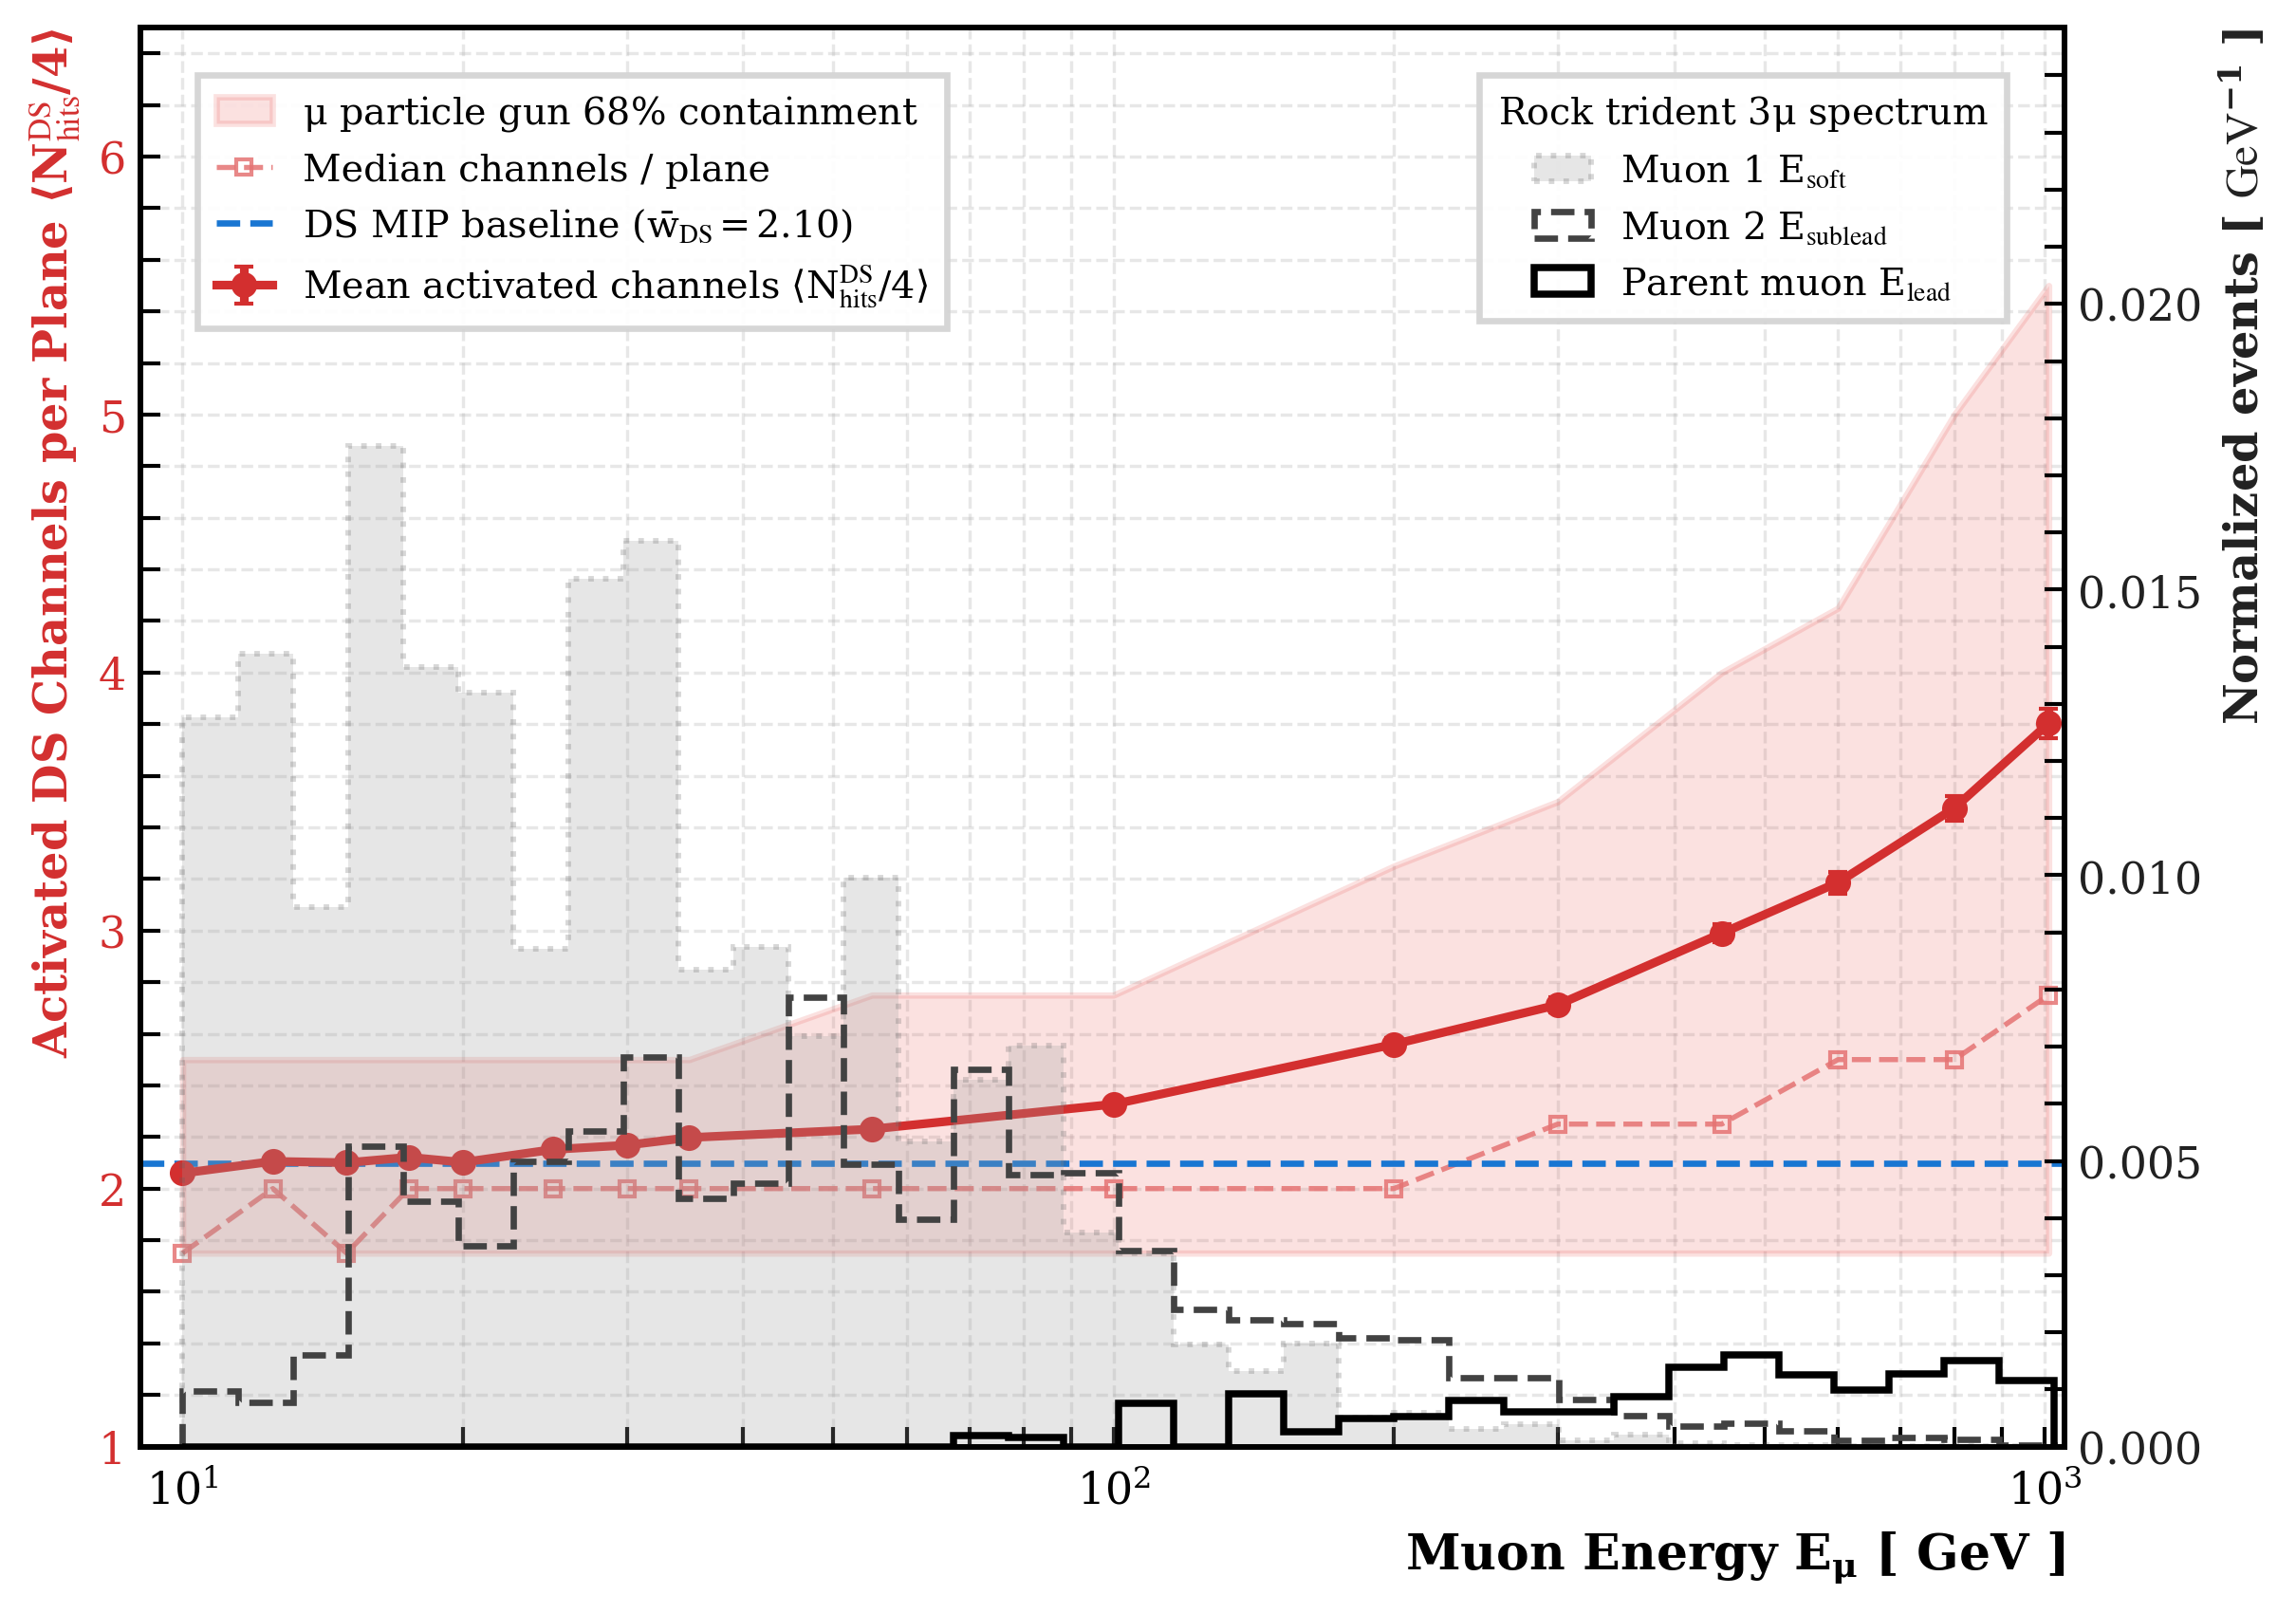

In [7]:
    from pathlib import Path
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker
    import numpy as np
    import pandas as pd
    import ROOT
    
    ROOT.gROOT.SetBatch(True)
    
    # ==============================================================================
    # 1. SCAN PARTICLE GUN ENERGY DIRECTORIES FOR DOWNSTREAM (DS, System 3)
    # ==============================================================================
    PGUN_DIR = Path("/eos/user/i/idioniso/1_Data/Monte_Carlo/pGun/muons")
    energy_dirs = [
        "10.GeV",
        "12.5.GeV",
        "15.GeV",
        "17.5.GeV",
        "20.GeV",
        "25.GeV",
        "30.GeV",
        "35.GeV",
        "55.GeV",
        "100.GeV",
        "200.GeV",
        "300.GeV",
        "450.GeV",
        "600.GeV",
        "800.GeV",
        "1010.GeV",
    ]
    
    results_ds = []
    
    for edir in energy_dirs:
      dir_path = PGUN_DIR / edir
      digi_file = dir_path / "sndLHC.PG_13-TGeant4_digCPP.root"
      if not digi_file.exists():
        continue
    
      energy_val = float(edir.replace(".GeV", "").replace("GeV", ""))
      f = ROOT.TFile.Open(str(digi_file))
      if not f or f.IsZombie():
        continue
    
      tree = f.Get("cbmsim")
      if not tree:
        f.Close()
        continue
    
      n_entries = min(4000, tree.GetEntries())
      hit_counts_ds = []
    
      for i in range(n_entries):
        tree.GetEntry(i)
        # Count Downstream hits (System == 3)
        n_ds = sum(1 for h in tree.Digi_MuFilterHits if h.GetSystem() == 3)
        if n_ds >= 2:  # Muon reached DS
          hit_counts_ds.append(n_ds)
    
      f.Close()
    
      if len(hit_counts_ds) > 0:
        arr = np.array(hit_counts_ds)
        mean_val = float(np.mean(arr))
        median_val = float(np.median(arr))
        sem_val = float(np.std(arr) / np.sqrt(len(arr)))
        q16 = float(np.percentile(arr, 16))
        q84 = float(np.percentile(arr, 84))
    
        # 4 DS tracking planes (DS1H, DS1V, DS2H, DS2V)
        results_ds.append({
            "energy_gev": energy_val,
            "mean_total_hits": mean_val,
            "median_total_hits": median_val,
            "sem_total_hits": sem_val,
            "q16_total_hits": q16,
            "q84_total_hits": q84,
            "mean_per_plane": mean_val / 4.0,
            "sem_per_plane": sem_val / 4.0,
            "median_per_plane": median_val / 4.0,
            "q16_per_plane": q16 / 4.0,
            "q84_per_plane": q84 / 4.0,
            "n_events": len(arr),
        })
    
    df_pgun_ds = pd.DataFrame(results_ds).sort_values(by="energy_gev")
    
    # ==============================================================================
    # 2. EXTRACT POST-SELECTION TRIDENT MUON ENERGIES FROM MC
    # ==============================================================================
    MC_PATH = Path(
        "/eos/user/i/idioniso/sndMuTri/data/cutset8/trimuon_boost100/trimuon_digCPP_hough_cutset8.parquet"
    )
    mc_df = pd.read_parquet(MC_PATH)
    sig_mc = mc_df[(mc_df["is_signal"] == 1) & (mc_df["region_type"] == 1)].copy()
    
    
    def apply_optimal_selection(df: pd.DataFrame) -> pd.DataFrame:
      """Applies [SF(3,0) | DS(3,0)] & (SF_nc & DS_nc) selection."""
    
      def check_nc(prefix, proj, z_min, z_max):
        n = df[f"n_lines_{prefix}_{proj}"].to_numpy()
        m1, c1 = df[f"{proj}_{prefix}_m1"].to_numpy(), df[
            f"{proj}_{prefix}_c1"
        ].to_numpy()
        m2, c2 = df[f"{proj}_{prefix}_m2"].to_numpy(), df[
            f"{proj}_{prefix}_c2"
        ].to_numpy()
        m3, c3 = df[f"{proj}_{prefix}_m3"].to_numpy(), df[
            f"{proj}_{prefix}_c3"
        ].to_numpy()
        x1_min, x1_max = m1 * z_min + c1, m1 * z_max + c1
        x2_min, x2_max = m2 * z_min + c2, m2 * z_max + c2
        x3_min, x3_max = m3 * z_min + c3, m3 * z_max + c3
        no_cross_12 = ((x1_min - x2_min) * (x1_max - x2_max)) > 0
        no_cross_13 = ((x1_min - x3_min) * (x1_max - x3_max)) > 0
        no_cross_23 = ((x2_min - x3_min) * (x2_max - x3_max)) > 0
        pass_3 = (n >= 3) & no_cross_12 & no_cross_13 & no_cross_23
        pass_2 = (n == 2) & no_cross_12
        return pass_3 | pass_2
    
      m_sf_xz = df["n_lines_sf_xz"] >= 3
      m_sf_yz = df["n_lines_sf_yz"] >= 3
      m_ds_xz = df["n_lines_ds_xz"] >= 3
      m_ds_yz = df["n_lines_ds_yz"] >= 3
      mult_mask = (m_sf_xz | m_sf_yz | m_ds_xz | m_ds_yz).to_numpy()
    
      coll_sf = check_nc("sf", "xz", 260.0, 355.0) | check_nc(
          "sf", "yz", 260.0, 355.0
      )
      coll_ds = check_nc("ds", "xz", 460.0, 590.0) | check_nc(
          "ds", "yz", 460.0, 590.0
      )
      return df[mult_mask & coll_sf & coll_ds].copy()
    
    
    sel_mc = apply_optimal_selection(sig_mc)
    
    # Compute individual muon energies
    m_mu = 0.10566
    e1 = np.sqrt(sel_mc["p_mu_in"] ** 2 + m_mu**2).to_numpy()
    e2 = np.sqrt(sel_mc["p_mu_minus"] ** 2 + m_mu**2).to_numpy()
    e3 = np.sqrt(sel_mc["p_mu_plus"] ** 2 + m_mu**2).to_numpy()
    e_mat = np.sort(np.vstack([e1, e2, e3]).T, axis=1)
    
    e_soft = e_mat[:, 0]
    e_sublead = e_mat[:, 1]
    e_lead = e_mat[:, 2]
    w_mc = sel_mc["mc_weight"].to_numpy()
    
    # ==============================================================================
    # 3. PUBLICATION-QUALITY DOWNSTREAM (DS) RESPONSE & ENERGY SPECTRUM PLOT
    # ==============================================================================
    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "font.size": 11,
        "axes.labelsize": 12.5,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 9.5,
    })
    
    fig, ax1 = plt.subplots(figsize=(8.2, 5.8), dpi=300)
    bins_energy = np.logspace(1.0, 3.01, 35)  # 10 GeV to ~1010 GeV
    
    # ------------------------------------------------------------------------------
    # 1. RIGHT AXIS (Background): Post-Selection Trident Muon Energy Hierarchy
    # ------------------------------------------------------------------------------
    ax1_twin = ax1.twinx()
    
    # Softest Muon
    ax1_twin.hist(
        e_soft,
        bins=bins_energy,
        weights=w_mc,
        density=True,
        histtype="stepfilled",
        facecolor="#9E9E9E",
        alpha=0.25,
        edgecolor="#616161",
        linestyle=":",
        linewidth=1.4,
        zorder=1,
        label=r"Muon 1 $E_{\mathrm{soft}}$",
    )
    
    # Sub-Leading Muon
    ax1_twin.hist(
        e_sublead,
        bins=bins_energy,
        weights=w_mc,
        density=True,
        histtype="step",
        color="#424242",
        linestyle="--",
        linewidth=1.6,
        zorder=2,
        label=r"Muon 2 $E_{\mathrm{sublead}}$",
    )
    
    # Leading Muon
    ax1_twin.hist(
        e_lead,
        bins=bins_energy,
        weights=w_mc,
        density=True,
        histtype="step",
        color="black",
        linestyle="-",
        linewidth=1.8,
        zorder=3,
        label=r"Parent muon $E_{\mathrm{lead}}$",
    )
    
    ax1_twin.set_ylabel(
        r"Normalized events [ $\mathrm{GeV}^{-1}$ ]",
        fontweight="bold",
        fontsize=11.5,
        color="#212121",
    )
    ax1_twin.tick_params(axis="y", labelcolor="#212121")
    ax1_twin.set_ylim(0, ax1_twin.get_ylim()[1] * 1.35)
    
    # ------------------------------------------------------------------------------
    # 2. LEFT AXIS (Foreground): Particle Gun DS Detector Response
    # ------------------------------------------------------------------------------
    # 68% containment interval band
    ax1.fill_between(
        df_pgun_ds["energy_gev"],
        df_pgun_ds["q16_per_plane"],
        df_pgun_ds["q84_per_plane"],
        color="#E53935",
        alpha=0.15,
        zorder=4,
        label=r"$\mu$ particle gun $68\%$ containment",
    )
    
    # Subtle Median response (dashed, in background)
    ax1.plot(
        df_pgun_ds["energy_gev"],
        df_pgun_ds["median_per_plane"],
        marker="s",
        markersize=3.8,
        markerfacecolor="none",
        markeredgecolor="#E57373",
        linestyle="--",
        color="#E57373",
        lw=1.3,
        alpha=0.85,
        zorder=5,
        label=r"Median channels / plane",
    )
    
    # Prominent Mean cluster size per plane
    ax1.errorbar(
        df_pgun_ds["energy_gev"],
        df_pgun_ds["mean_per_plane"],
        yerr=df_pgun_ds["sem_per_plane"],
        fmt="o-",
        color="#D32F2F",
        ecolor="#D32F2F",
        lw=2.2,
        markersize=5.5,
        capsize=2.5,
        zorder=7,
        label=r"Mean activated channels $\langle N_{\mathrm{hits}}^{\mathrm{DS}} / 4 \rangle$",
    )
    
    # DS MIP Plateau reference line (bar width ~ 1 cm -> w_DS ~ 2.10)
    ax1.axhline(
        2.10,
        color="#1976D2",
        linestyle="--",
        lw=1.6,
        zorder=6,
        label=r"DS MIP baseline ($\bar{w}_{\mathrm{DS}} = 2.10$)",
    )
    
    ax1.set_xscale("log")
    ax1.set_xlim(9, 1050)
    ax1.set_ylim(1.0, 6.5)  # Appropriately scaled for Downstream bar geometry
    
    ax1.set_xlabel(r"Muon Energy $E_{\mu}$ [ GeV ]", fontweight="bold")
    ax1.set_ylabel(
        r"Activated DS Channels per Plane $\langle N_{\mathrm{hits}}^{\mathrm{DS}} /"
        r" 4 \rangle$",
        fontweight="bold",
        fontsize=11.5,
        color="#D32F2F",
    )
    ax1.tick_params(axis="y", labelcolor="#D32F2F")

    # Minor tick formatters
    ax1.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs="auto"))
    ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax1_twin.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    ax1.tick_params(
        which="both", direction="in", top=False, right=False, length=5, width=1.0
    )
    ax1_twin.tick_params(
        which="both", direction="in", top=False, right=True, length=5, width=1.0
    )
    ax1.grid(True, which="both", linestyle="--", alpha=0.3)

    # ------------------------------------------------------------------------------
    # 3. SPLIT LEGENDS FOR READABILITY
    # ------------------------------------------------------------------------------
    # Left Legend: Detector Calibration / Particle Gun (DS)
    ax1.legend(
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        frameon=True,
        framealpha=0.92,
        edgecolor="lightgray",
        title_fontsize=9.5,
    )

    # Right Legend: Trident Kinematics
    ax1_twin.legend(
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98),
        frameon=True,
        framealpha=0.92,
        edgecolor="lightgray",
        title=r"Rock trident $3\mu$ spectrum",
        title_fontsize=9.5,
    )

    plt.tight_layout()
    plt.show()